# 01 — Data Exploration

Inspect the raw landscape CSV: class balance, enrichment distributions,
mutation count histograms, and sequence diversity across sublibraries.
Run this before training to verify the preprocessing pipeline output.

In [ ]:
#troubleshooting the kernel
import sys; print(sys.executable)

## to create the environment:
# # 1. create the env
# conda create -n nucb_env python=3.11 -y

# # 2. activate it
# conda activate nucb_env

# # 3. install the repo and all dependencies
# pip install -e ".[dev]"


/Users/zahmiriajohnson/opt/miniconda3/envs/nucb_env/bin/python


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from nucb_transformer.data.dataset import load_landscape
from nucb_transformer.data.splits import mutation_count_split

In [3]:
import matplotlib.patches as mpatches

In [4]:
df = load_landscape()
train_df, val_df, test_df = mutation_count_split(df)

train_pool = df[df["num_mutations"] <= 2]  # train + val together

print(f"Train pool (\u22642 mut): {len(train_pool):,}  |  Test (>2 mut): {len(test_df):,}  |  Total: {len(df):,}")

Train pool (≤2 mut): 13,066  |  Test (>2 mut): 42,694  |  Total: 55,760


In [11]:
CLASS_COLORS = {
    "non-functional":  "#C99DA3",
    "activity > 0":    "#996888",
    "activity > WT":   "#5E4955",
    "activity > A73R": "#2A2B2A",
}

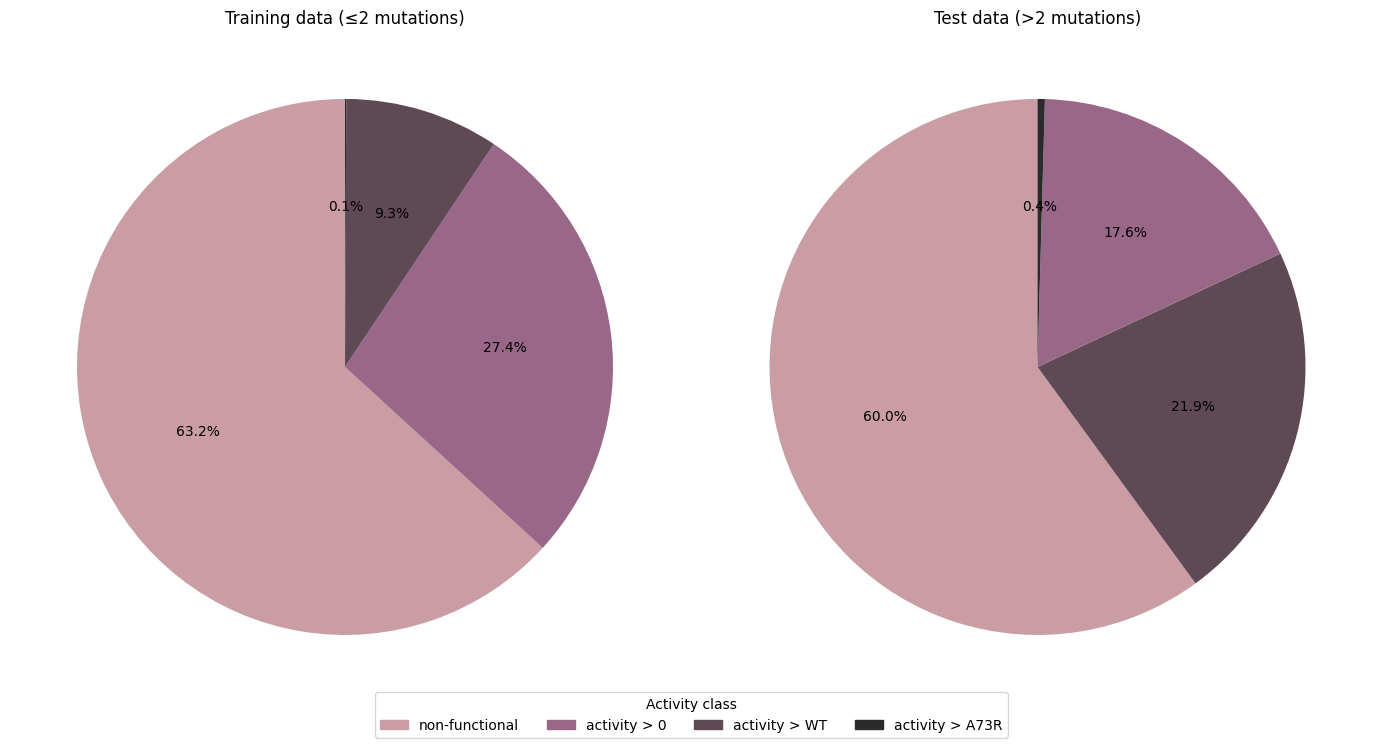

In [12]:
# Pies
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Pie 1: training data (<=2 mutations)
counts = train_pool["activity_level"].value_counts()
ax[0].pie(
    counts,
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=90,
)
ax[0].set_title("Training data (\u22642 mutations)")

# Pie 2: test data (>2 mutations)
counts = test_df["activity_level"].value_counts()

ax[1].pie(
    counts,
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=90,
)
ax[1].set_title("Test data (>2 mutations)")

handles = [mpatches.Patch(color=v, label=k) for k, v in CLASS_COLORS.items()]
fig.legend(handles=handles, title="Activity class", loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04))


plt.tight_layout()
plt.show()


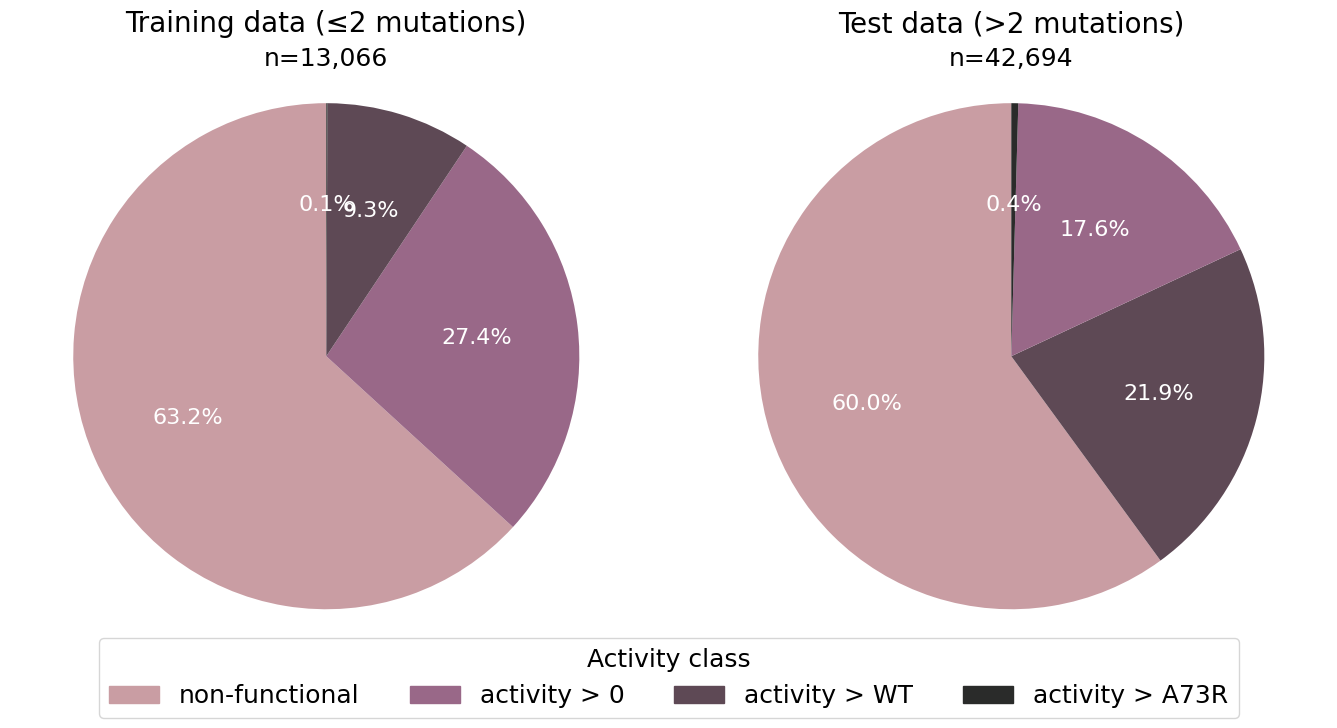

In [25]:
plt.rcParams.update({"font.size": 20})

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

counts = train_pool["activity_level"].value_counts()
ax[0].pie(
    counts,
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 16, "color": "white"},
)
ax[0].set_title("Training data (≤2 mutations)", fontsize=20)
ax[0].text(0, 1.15, f"n={len(train_pool):,}", ha="center", fontsize=18, color="black")

counts = test_df["activity_level"].value_counts()
ax[1].pie(
    counts,
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 16, "color": "white"},
)
ax[1].set_title("Test data (>2 mutations)", fontsize=20)
ax[1].text(0, 1.15, f"n={len(test_df):,}", ha="center", fontsize=18, color="black")

handles = [mpatches.Patch(color=v, label=k) for k, v in CLASS_COLORS.items()]
fig.legend(handles=handles, title="Activity class", title_fontsize=18,
           fontsize=18, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()


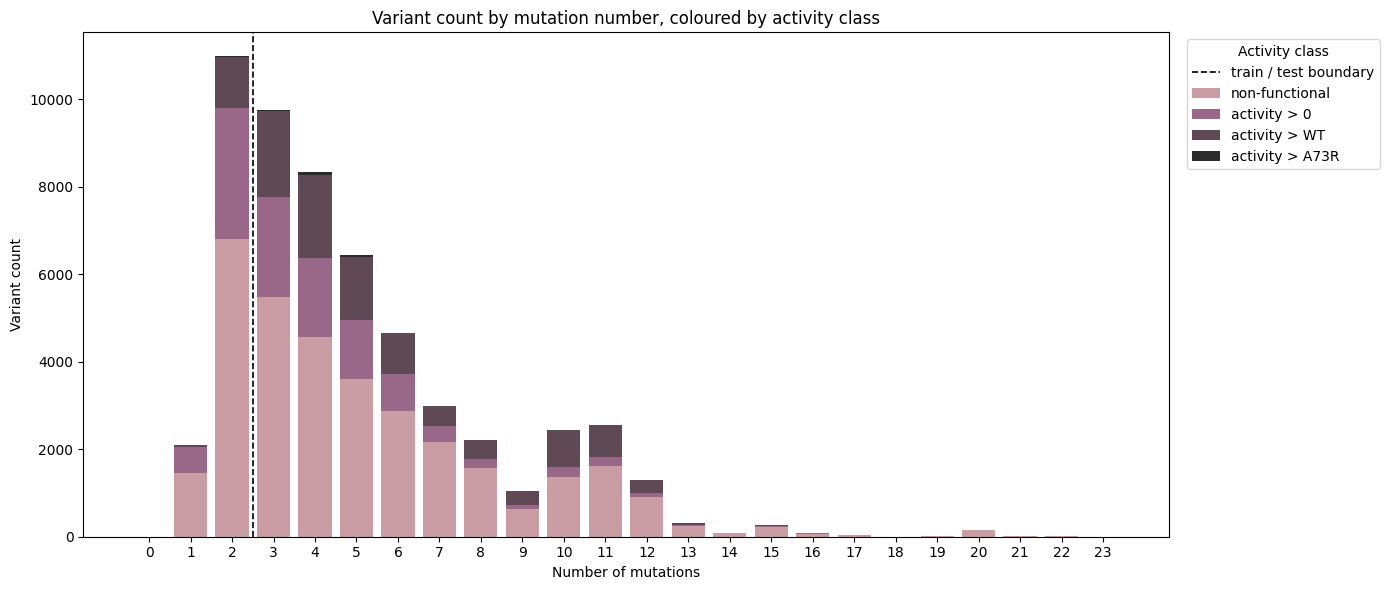

In [14]:
# Stacked bar: variant count by mutation number, coloured by activity class
class_order = ["non-functional", "activity > 0", "activity > WT", "activity > A73R"]

pivot = (
    df.groupby(["num_mutations", "activity_level"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot[[c for c in class_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 6))
bottom = pd.Series(0, index=pivot.index)
for cls in pivot.columns:
    ax.bar(pivot.index, pivot[cls], bottom=bottom, label=cls, color=CLASS_COLORS[cls])
    bottom = bottom + pivot[cls]

ax.axvline(x=2.5, color="black", linestyle="--", linewidth=1.2, label="train / test boundary")
ax.set_xlabel("Number of mutations")
ax.set_ylabel("Variant count")
ax.set_title("Variant count by mutation number, coloured by activity class")
ax.set_xticks(pivot.index)
ax.legend(title="Activity class", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
import ast
import numpy as np
import matplotlib.colors as mcolors

SEQ_LEN = 142

# sort: train pool first, then test
df_sorted = pd.concat([
    train_pool.reset_index(drop=True),
    test_df.reset_index(drop=True),
]).reset_index(drop=True)

n_seqs  = len(df_sorted)
n_train = len(train_pool)

# build binary mutation matrix — (n_seqs, SEQ_LEN)
mut_matrix = np.zeros((n_seqs, SEQ_LEN), dtype=np.uint8)
for i, row in enumerate(df_sorted["mutations"]):
    for _, pos, _ in ast.literal_eval(row):
        if 1 <= pos <= SEQ_LEN:
            mut_matrix[i, pos - 1] = 1

# RGB array for activity class color strip — (n_seqs, 1, 3)
rgb_strip = np.array([
    mcolors.to_rgb(CLASS_COLORS[a]) for a in df_sorted["activity_level"]
])[:, np.newaxis, :]

fig, (ax_strip, ax_main) = plt.subplots(
    1, 2, figsize=(16, 10),
    gridspec_kw={"width_ratios": [0.025, 1], "wspace": 0.01},
)

# activity class color strip
ax_strip.imshow(rgb_strip, aspect="auto", interpolation="nearest")
ax_strip.set_xticks([])
ax_strip.set_yticks([])
ax_strip.set_ylabel("Sequence index", fontsize=10)

# mutation map
ax_main.imshow(mut_matrix, cmap="Greys", aspect="auto",
               interpolation="nearest", vmin=0, vmax=1)
ax_main.axhline(n_train - 0.5, color="tomato", linestyle="--", linewidth=1.2)
ax_main.set_xlabel("Residue position", fontsize=10)
ax_main.set_yticks([])
ax_main.set_xticks(range(0, SEQ_LEN, 10))
ax_main.set_xticklabels(range(1, SEQ_LEN + 1, 10), fontsize=8)
ax_main.text(1, n_train - 2,        "← train (≤2 mut)", va="bottom", fontsize=8, color="tomato")
ax_main.text(1, n_train + 2, "← test  (>2 mut)", va="top",    fontsize=8, color="tomato")
ax_main.set_title("Mutation map — rows: variants, columns: residue positions", fontsize=11)

handles = [mpatches.Patch(color=v, label=k) for k, v in CLASS_COLORS.items()]
fig.legend(handles=handles, title="Activity class", loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.01), fontsize=9)

plt.tight_layout()
plt.show()


ValueError: malformed node or string: ()